In [3]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from glob import glob
import pandas as pd
import json
import os


In [6]:
ds = xr.load_dataset('../data/swift/doi_10_5061_dryad_hx3ffbgk0__v20230321/mission_32.nc')
ds

<xarray.Dataset> Size: 9MB
Dimensions:                  (time: 7921, trajectory: 7, single_value: 1)
Coordinates:
  * time                     (time) datetime64[ns] 63kB 2021-10-13T17:20:00 ....
  * trajectory               (trajectory) int32 28B 49 41 23 17 43 16 42
    latitude                 (trajectory, time) float64 444kB 36.19 ... 36.18
    longitude                (trajectory, time) float64 444kB -75.75 ... -75.75
Dimensions without coordinates: single_value
Data variables: (12/20)
    gps_freq                 (single_value) int32 4B 4
    imu_freq                 (single_value) int32 4B 12
    acceleration_x_body      (trajectory, time) float64 444kB -0.09093 ... -0...
    acceleration_y_body      (trajectory, time) float64 444kB 1.067 ... 1.397
    acceleration_z_body      (trajectory, time) float64 444kB 11.18 ... 10.95
    rotation_rate_x          (trajectory, time) float64 444kB 163.1 ... -56.75
    ...                       ...
    velocity_ew              (trajectory, time) float64 444kB 0.0 0.0 ... -1.998
    velocity_ns              (trajectory, time) float64 444kB 0.0 0.0 ... -0.703
    velocity_ud              (trajectory, time) float64 444kB nan nan ... nan
    xFRF                     (trajectory, time) float64 444kB 199.7 ... 216.9
    yFRF                     (trajectory, time) float64 444kB 959.9 ... 741.1
    sea_surface_elevation    (trajectory, time) float64 444kB nan nan ... nan
Attributes: (12/30)
    title:                 DUNEX microSWIFT drifter - Mission 32
    summary:               University of Washington - Applied Physics Lab tea...
    institution:           University of Washington - Applied Physics Lab
    source:                Observations from microSWIFT drifters deployed in ...
    Conventions:           CF-1.6
    Metadata_Conventions:  Unidata Dataset Discovery v1.0
    ...                    ...
    deployment_method:     jetski
    array_type:            along shore lines on north side of pier but asked ...
    mission_start_time:    2021-10-13T17:20:00
    mission_end_time:      2021-10-13T17:31:00
    deployment_notes:      Instructed to place closer alongshore spacing
    data_cleaning_notes:   Mission 32(Cleaned on 02/15/22): Adjusted end time...

: 

In [5]:
print(ds.time.min())
print(ds.time.max())

<xarray.DataArray 'time' ()> Size: 8B
array('2021-10-13T17:20:00.000000000', dtype='datetime64[ns]')
<xarray.DataArray 'time' ()> Size: 8B
array('2021-10-13T17:30:59.997359872', dtype='datetime64[ns]')


In [5]:
(ds.time.max() - ds.time.min())/1e9/60

<xarray.DataArray 'time' ()> Size: 8B
array(10, dtype='timedelta64[ns]')

Text(0.5, 1.0, 'SWIFT Trajectories\nMission 32\n10/13/2021')

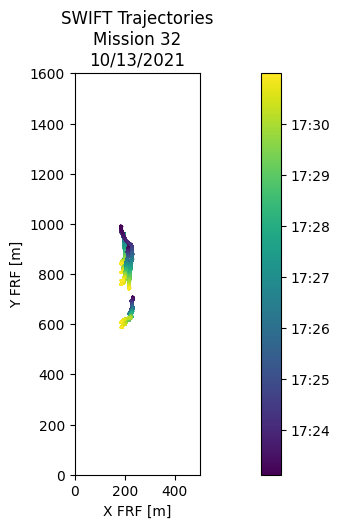

In [34]:
import matplotlib.dates as mdates
for i in ds.trajectory:
    s = ds.where(ds.trajectory == i, drop=True)
    plt.scatter(s.xFRF.squeeze(), s.yFRF.squeeze(), 
                c=mdates.date2num(s.time), s=1)
from matplotlib.dates import DateFormatter,HourLocator

cb = plt.colorbar(pad=0.1)
loc = mdates.AutoDateLocator()
cb.ax.yaxis.set_major_locator(loc)
cb.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.xlabel('X FRF [m]')
plt.ylabel('Y FRF [m]')
plt.gca().set_aspect(1)
plt.xlim(0, 500)
plt.ylim(0, 1600)
plt.tight_layout()
plt.title(f'SWIFT Trajectories\nMission 32\n{ds.time[0].dt.strftime('%m/%d/%Y').item()}')

In [2]:
times_fn = '../data/swift/time_extents.json'
if not os.path.exists(times_fn):
    time_fmt = '%Y%m%dT%H%M%SZ'
    import json
    print('doin')
    time_extents = {}
    for fname in glob('../data/swift/**/*.nc'):
        print(fname)
        ds = xr.load_dataset(fname)
        print(ds.time.min())
        time_extents[id] = dict(
            min = pd.to_datetime(ds.time.min().item()).strftime(time_fmt),
            max = pd.to_datetime(ds.time.max().item()).strftime(time_fmt)
        )
        
    with open(times_fn, 'w', encoding='utf-8') as f:
        json.dump(time_extents, f, indent=4)
else:
    with open(times_fn, 'r', encoding='utf-8') as f:
        time_extents = json.load(f)

print(time_extents)

start = []
end = []
for key, values in time_extents.items():
    c = [int(re.split('_|\.', key)[-2])]
    plt.scatter([pd.to_datetime(values['min'], format=time_fmt), pd.to_datetime(values['max'], format=time_fmt)], [1, 1], c=[int(re.split(r'_|\.', key)[-2])]*2, s=10, vmin=0, vmax=81)
    plt.plot([pd.to_datetime(values['min']), pd.to_datetime(values['max'])], [1, 1], c='k')
plt.colorbar()
plt.xticks(rotation=15)
    

<>:28: SyntaxWarning: invalid escape sequence '\.'
<>:28: SyntaxWarning: invalid escape sequence '\.'
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_96158/4270244678.py:28: SyntaxWarning: invalid escape sequence '\.'
  c = [int(re.split('_|\.', key)[-2])]
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_96158/4270244678.py:28: SyntaxWarning: invalid escape sequence '\.'
  c = [int(re.split('_|\.', key)[-2])]


NameError: name 'os' is not defined

(array([18905., 18909., 18913., 18917., 18921., 18925., 18929.]),
 [Text(18905.0, 0, '2021-10-05'),
  Text(18909.0, 0, '2021-10-09'),
  Text(18913.0, 0, '2021-10-13'),
  Text(18917.0, 0, '2021-10-17'),
  Text(18921.0, 0, '2021-10-21'),
  Text(18925.0, 0, '2021-10-25'),
  Text(18929.0, 0, '2021-10-29')])

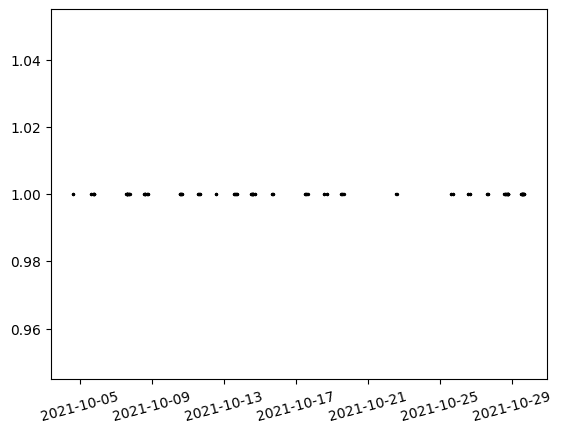

In [75]:
start = []
end = []
for values in time_extents.values():
    plt.scatter([pd.to_datetime(values['min']), pd.to_datetime(values['max'])], [1, 1], c='k', s=2)
    plt.plot([pd.to_datetime(values['min']), pd.to_datetime(values['max'])], [1, 1], c='k')
plt.xticks(rotation=15)
    

In [20]:
te = json.load(open('../data/swift/time_extents.json'))

In [1]:
plt.hist(list(map(lambda v: (v['max']-v['min']).seconds*2*800000/1000/1000/1000, time_extents.values())), density=True)
plt.xlabel('Minutes')
plt.title('Mission Duration Distribution')

NameError: name 'plt' is not defined